# Big Data y Machine Learning (UBA) 

## Trabajo Práctico 1: Jugando con APIs y WebScraping 

### Reglas de formato y presentación
- El trabajo debe estar debidamente documentado comentado (utilizando #) para que tanto los docentes como sus compañeros puedan comprender el código fácilmente.

- El mismo debe ser completado en este Jupyter Notebook y entregado como tal, es decir en un archivo .ipynb


### Fecha de entrega:
<font color=red>Martes 31 de Marzo a las 13:00 hs</font> 

### Modalidad de entrega
- Al finalizar el trabajo práctico deben hacer un último <i>commit</i> en su repositorio de GitHub llamado “Entrega final del tp”. 
- Asegurense de haber creado una carpeta llamada TP1. Este Jupyter Notebook y el correspondiente al TP1 deben estar dentro de esa carpeta.
- También deben incorporar el link de su repositorio -para que pueda ser clonado y corregido- en su informe final. Nombrar los archivos <i>"UBA_TP1_Grupo_#"</i> donde # es el número de grupo que le fue asignado.
- La última versión en el repositorio es la que será evaluada. Por lo que es importante que: 
    - No envien el correo hasta no haber terminado y estar seguros de que han hecho el <i>commit y push</i> a la versión final que quieren entregar. 
    - No hagan nuevos <i>push</i> despues de haber entregado su versión final. Esto generaría confusión acerca de que versión es la que quieren que se les corrija.
- En resumen, la carpeta del repositorio debe incluir:
    - El codigo
    - Un documento Word (Parte A) donde esten las figuras y una breve descripción de las mismas.
    - El excel con los links webscrappeados (Parte B)
    - Slides para presentar en el sorteo de exposición grupal

### Parte A

#### Ejercicio 1 - Jugando con APIs
Usando la API del Series de Tiempo de la Republica Argentina [link](https://datosgobar.github.io/series-tiempo-ar-api/applications/) , obtener 2 (dos) series de indicadores del **Ministerio de Justicia y Derechos Humanos de la Nación**. En total, dicho Ministerio tiene **575** series anuales y pueden buscar dos series de indicadores de su interés.

In [49]:
import requests
import pandas as pd

# defino los URL de ambas series
url2534 = "https://apis.datos.gob.ar/series/api/series?ids=sneep_re4_42&format=json&limit=1000"
url4554 = "https://apis.datos.gob.ar/series/api/series?ids=sneep_re6_42&format=json&limit=1000"

# defino los dataframe de las series segun su request
df1 = requests.get(url2534).json()["data"]
lib25_35 = pd.DataFrame(df1, columns=["fecha", "Mujeres 25-34"]).set_index("fecha")

df2 = requests.get(url4554).json()["data"]
lib45_54 = pd.DataFrame(df2, columns=["fecha", "Mujeres 45-54"]).set_index("fecha")

# uno ambos dataframe
lib_sante_fe = pd.concat([lib25_35, lib45_54], axis=1)

print(lib_sante_fe.head())

            Mujeres 25-34  Mujeres 45-54
fecha                                   
2002-01-01           13.0            1.0
2003-01-01           19.0            4.0
2004-01-01           17.0            8.0
2005-01-01           40.0           12.0
2006-01-01           42.0           12.0


#### Ejercicio 2 - Repaso de Pandas
Realicen una estadistica descriptiva ambas series de indicadores del Ministerio y  presente en una tabla en su reporte. Dicha tabla debe mostrar: numero de observaciones, media, desvío standard, min, p25, mediana, p75 y max. Comente la tabla en **el reporte**.

In [36]:
# en la estadística descriptiva uso la función .describe, que brinda lo pedido por el ejercicio
desc = lib_sante_fe.describe()

print(desc)

       Mujeres 25-34  Mujeres 45-54
count      23.000000      23.000000
mean       73.739130      24.434783
std        39.846544      19.653420
min        13.000000       1.000000
25%        41.000000      11.000000
50%        66.000000      18.000000
75%       109.000000      34.000000
max       133.000000      68.000000


#### Ejercicio 3 - Practicando con Matplotlib
Armen dos gráficos de tendencia distintos usando la librería Matplotlib (repasen Clase 2). Uno programándolo con el estilo `pyplot` y otro gráfico de estilo `orientada a objetos`.
Recuerde los principios de visualización de datos y comente dichas figuras en su reporte.

In [37]:
import matplotlib.pyplot as plt

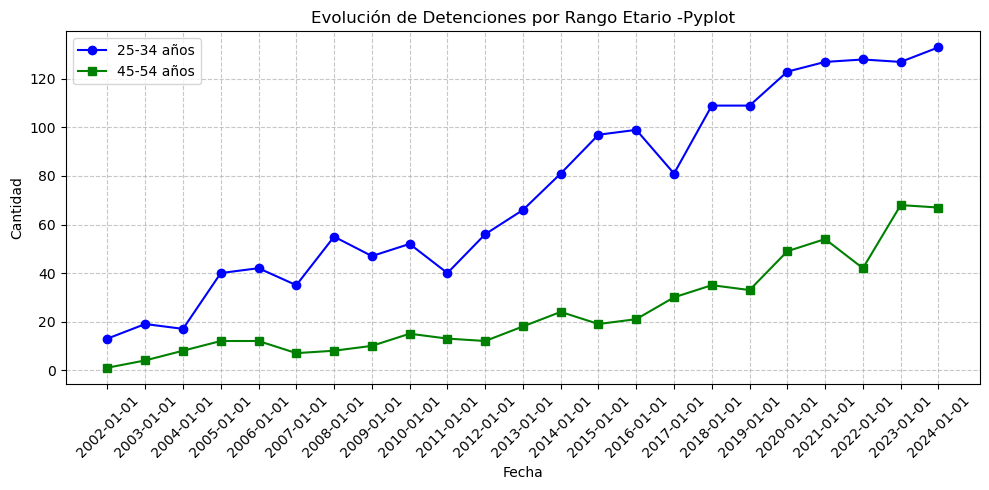

In [38]:
#gráfico con pyplot
#defino tamaño y contenido
plt.figure(figsize=(10, 5))
plt.plot(lib_sante_fe.index, lib_sante_fe["Mujeres 25-34"], label="25-34 años", color="blue", marker="o")
plt.plot(lib_sante_fe.index, lib_sante_fe["Mujeres 45-54"], label="45-54 años", color="green", marker="s")

#determinación de títulos y comentarios
plt.title("Evolución de Detenciones por Rango Etario -Pyplot")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.xticks(rotation=45) # Rotamos las fechas para que se lean bien
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


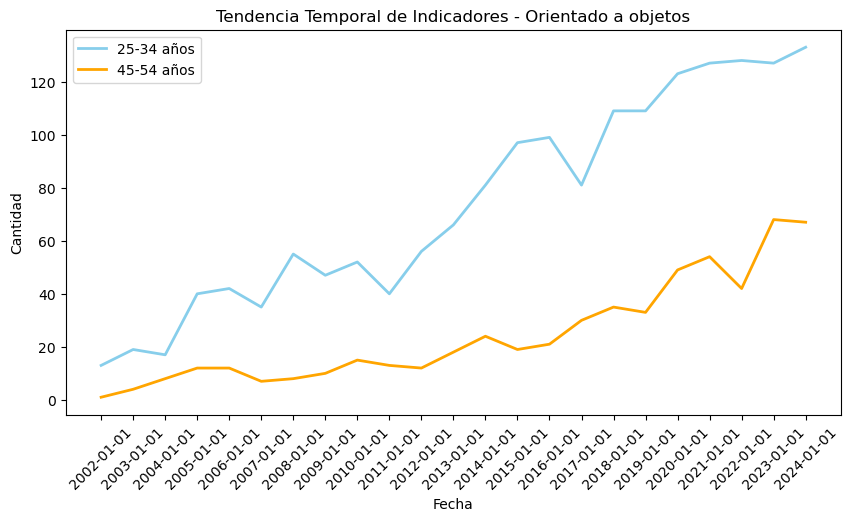

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

#determino contenidos
ax.plot(lib_sante_fe.index, lib_sante_fe["Mujeres 25-34"], label="25-34 años", color="skyblue", linewidth=2)
ax.plot(lib_sante_fe.index, lib_sante_fe["Mujeres 45-54"], label="45-54 años", color="orange", linewidth=2)

#título y comentarios
ax.set_title("Tendencia Temporal de Indicadores - Orientado a objetos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.show()

### Parte B

#### Ejercicio 4 - Documentando noticias locales y en el extranjero
Eligan dos sitios web de noticias: uno de Argentina y uno del extranjero (puede ser en castellano o en inglés como el *New York Times*).

Utilicen herramientas de webscraping para obtener los **links** de las noticias de la portada en ambos diarios. Guarden cada titular con los links obtenidos en un dataframe. Por lo tanto, debe quedarles un dataframe de 4 columnas: una columna para noticias locales, otra para su link, otra columna de noticias extranjeras y una ultima columna de sus links. Luego, expórtenlo a un archivo de excel.

En el reporte este esta parte B:
1) Inserten una captura de pantalla de la pagina del diario extranjero y en Argentina de las cuales hacen el ejercicio de extraer titulares y sus links correspondientes. Esto servirá al momento de la corrección para verificar que los links obtenidos hacen referencia a las noticias de ese día y hora.
2) Comenten brevemente (1 párrafo) las diferencias/similitudes al extraer titulares en diarios de Argentina versus diario extranjero
3) Comenten brevemente (1 párrafo) las dificultades y cómo resolvieron dichas dificultades.

*Nota*: es posible que logren obtener los links a las noticias sin el dominio: por ejemplo "https://www.lanacion.com.ar/". De ser así, concatenen el dominio a la ruta del link obtenido, tal que se obtenga un link al que se pueda acceder. Es decir, que las cadenas de caracteres finales tendrán la forma: https://www.lanacion.com.ar/*texto_obtenido*)

In [40]:
from bs4 import BeautifulSoup 


In [45]:
#Uso del portal de ámbito financiero - argentino
url_arg = "https://www.ambito.com/"
headers = {
   'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

r_arg = requests.get(url_arg, headers=headers) #request al portal
soup_arg = BeautifulSoup(r_arg.content, "html.parser")

#listas donde se guardan links y títulos
titulos_arg = []
links_arg = []

#se buscan todos las noticias con formato h2
noticias_arg = soup_arg.find_all("h2", class_="news-article__title")

#for para iterar sobre cada noticia
for noti in noticias_arg:
    enlace = noti.find("a")
    if enlace:
        titulos_arg.append(enlace.text.strip()) #guardar título iterado en la lista
        link = enlace.get("href") # get() es más seguro que ["href"] por si el atributo no existe
        # concatenar en caso de que el link no este completo
        if not link.startswith("http"):
            link = "https://www.ambito.com" + link
            
        links_arg.append(link)

print("Se encontraron", len(links_arg), "noticias.")
print(titulos_arg[:5]) 

Se encontraron 138 noticias.
['La inversión profundizó su caída en febrero: se hundió 11,4% anual, arrastrada por menor compra de equipos importados', 'Medio Oriente en guerra: se intensifica la disputa entre el dólar y el yuan por el control del comercio petrolero', 'La Justicia frenó por ahora la reforma laboral: hizo lugar a una cautelar pedida por la CGT', 'Deuda en dólares: Economía solo colocó u$s34 millones del nuevo Bonar 2028 en la segunda vuelta de la licitación', 'Interna en radicalismo bonaerense: Lousteau, cada vez más lejos de ser un referente para la UCR']


In [47]:
#Uso del portal de yahoo finance - estadounidense
url_usa = "https://finance.yahoo.com/"

#header tan diferente al de ámbito porque tiene un nivel más alto de ciberseguridad
headers_usa = {
   'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Accept-Language': 'en-US,en;q=0.9,es;q=0.8',
    'Accept': 'text/html,application/xhtml+xml',
    'Referer': 'https://www.google.com/'
}

r_usa = requests.get(url_usa, headers=headers_usa) #request al portal
soup_usa = BeautifulSoup(r_usa.content, "html.parser")

#listas donde se guardan links y títulos
titulos_usa = []
links_usa = []

# noticia principal con formato h2
noticias_principales = soup_usa.find_all("h2", attrs={"data-testid": "title"})
# noticias secundarias con formato h3
noticias_secundarias = soup_usa.find_all("h3")
# se juntan ambas noticias
todas_las_noticias = noticias_principales + noticias_secundarias

# for para iterar sobre todas las noticias
for new in todas_las_noticias:
    texto_titulo = new.text.strip()
    enlace = new.find_parent("a")
    
    if enlace and enlace.get("href"):
        link_usa = enlace.get("href")   
       # concatenar en caso de que el link no este completo
        if not link_usa.startswith("http"):
            link_usa = "https://finance.yahoo.com" + link_usa
            
        titulos_usa.append(texto_titulo)
        links_usa.append(link_usa)

print("Se encontraron", len(links_usa), "noticias.")
print(titulos_usa[:5])

Se encontraron 22 noticias.
['US stock futures soar as Trump states war may end with Hormuz shut', "Musk escalates feud with Delaware judge over 'heart' on a LinkedIn post", "Powell: No threat of private credit 'contagion,' rates in a 'good place'", 'Trump tells aides he is willing to end Iran war without reopening Hormuz', 'China factory activity rebounds in March as Iran war looms over growth']


In [48]:
#genero dataframe con las cuatro columnas
df_portales = pd.DataFrame({
    "Titulos_USA": pd.Series(titulos_usa),
    "Links_USA": pd.Series(links_usa),
    "Titulos_ARG": pd.Series(titulos_arg),
    "Links_ARG": pd.Series(links_arg)
})

# Exportación a excel
df_portales.to_excel("monitoreo_portales.xlsx", index=False)